### 3D City Models from Volunteered Public Data (No Internet)

<div class="alert alert-block alert-info""><b>This is a stand-alone Notebook for use in low resource settings. NO internet connection is necessary.</b> 

<br>
<br>

While an internet connection is **NOT** necessary you will **NEED** to have sourced an **[osm.pbf](https://wiki.openstreetmap.org/wiki/PBF_Format)**.

If you would like to do the entire Notebook and estimate the **Annual Average Solar Potential, per home** you will **NEED** to have sourced a **ghi.tif**.  
A **ghi.tif** raster comes with the **LTAy_YearlySum.GeoTiff** dataset.  
These can be harvested from the **[Global Solar Atlas download section](https://globalsolaratlas.info/download/) and are available for each country on Earth.**
</div>

<div class="alert alert-block alert-warning"><b>This notebook will:</b>

> **1. produce an [interactive *pseudo-3D* Building Model visualization](#Section1)** *- which a user can navigate, query, share* **that**;
> > **i) [colour buildings by type](#Section1a)** *(to easily visualize building stock)*  
>
> **2. allow the user to execute an application of Spatial Data Science**  
>
>> **i)  [population estimation](#Section2a)** _--with a previous census metric population growth rate and projected (future) population are also possible_  **and**    
>> **ii)  a measure of [Building Volume per Capita](#Section2b).**
>
> **3. further applications of Spatial Data Science**  
>
>> **a.**  calculate **percentage homes and population with direct access to on-site renewable energy infrastructure** *--rooftop photovoltaic panels (PV) and solar water heaters*
>>
>> **b.** estimate the [**Annual Average Solar** *(photovoltaic)* **Potential**](https://www.worldbank.org/en/topic/energy/publication/solar-photovoltaic-power-potential-by-country), per home. 
>
> **4. propose several [Geography and Sustainable Development Education *conversation starters*](#Section3) for Secondary and Tertiary level students** 

</div>

<div class="alert alert-block alert-danger"><b></b>

***The [suburb](https://github.com/AdrianKriger/geo3D/tree/main/suburb)*** processing option is meant for areas with more than for **2 500 buildings**.</div>

In [1]:
#load the magic
%matplotlib inline

import time
from datetime import timedelta

import os
import sys
import threading
import logging
import requests
import overpass
import webbrowser

import json
import geojson
import numpy as np
import pandas as pd
import shapely
from shapely.geometry import Polygon, shape, mapping
from shapely.ops import transform
from shapely.strtree import STRtree

import pyproj
from osgeo import gdal, ogr, osr

from openlocationcode import openlocationcode as olc

import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection

In [2]:
#- get current working directory (notebook location)
current_dir = os.getcwd()

#- go one level up
parent_dir = os.path.dirname(current_dir)
# Add parent directory to sys.path if needed
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

#- import
import city3D

In [3]:
Tstart = time.time()

In [4]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
jparams = json.load(open('../param/wStock_param.json'))   
#jparams = json.load(open('../param/sRiver_param.json'))    

**Harvest [OpenStreetMap](https://en.wikipedia.org/wiki/OpenStreetMap)** - interogate an osm.pbf (["Protocolbuffer Binary Format"](https://wiki.openstreetmap.org/wiki/PBF_Format)) from within Jupyter and convert to .geojson.

<div class="alert alert-block alert-info"><b></b> 
    
**PLEASE SUPPLY YOUR OWN [osm.pbf](https://wiki.openstreetmap.org/wiki/PBF_Format).**  

**Either crop an area directly from [OpenStreetMap]() with the ***[official tool](https://www.openstreetmap.org/export#map=3/0.70/22.15)***, select a predefined area [from any number of providers](https://wiki.openstreetmap.org/wiki/Planet.osm), such as ***[Geofabrik](https://download.geofabrik.de)***, or...**
</div>

<div class="alert alert-block alert-success"><b></b>
    
**... download your own. Provincial extracts for South Africa are available here:** *http://download.openstreetmap.fr/extracts/africa/south_africa/*</div>

In [6]:
# Input OSM PBF file
input_pbf = "../data/CapeTown.osm.pbf"
#input_pbf = "./data/western_cape-latest.osm.pbf" 

**[pydeck](https://deckgl.readthedocs.io/en/latest/) needs an area and a center**, harvest from osm.

In [7]:
start = time.time()

aoi = city3D.extract_boundaries_by_name(input_pbf, jparams)#, country='yes', place_type='neighbourhood')

end = time.time()
#print('runtime:', str(timedelta(seconds=(end - start))))

#- suppose 'aoi' is your GeoDataFrameLite or list of geometries
ageoms = aoi['geometry'].tolist()
#- combine all geometries into a single union
combined_ageom = shapely.unary_union(ageoms)  # returns Polygon or MultiPolygon
#- compute bounding box
minx, miny, maxx, maxy = combined_ageom.bounds
#extent = [minx - 250, miny - 250,maxx + 250, maxy + 250]
aoi.head(2)

,boundary,geometry,name,osm_id,other_tags,place,type
0,place,"MULTIPOLYGON (((18.4407807 -33.9286635, 18.440...",Woodstock,2034285,"""wikidata""=>""Q3644460""",suburb,boundary


**Only harvest what we need from the osm.pbf.**

In [8]:
start = time.time()

gdal.UseExceptions()
gdal.SetConfigOption("OGR_GEOMETRY_ACCEPT_UNCLOSED_RING", "NO") 
#gdal.SetConfigOption("USE_CUSTOM_INDEXING", "NO")

# GDAL Virtual File System (VSI) to avoid writing to disk
geojson_vsimem = "/vsimem/temp.geojson"

#- GDAL VectorTranslate to extract only buildings & fix geometries
gdal.VectorTranslate(
    geojson_vsimem,                                           # Output as in-memory GeoJSON
    input_pbf,                                                # Source OSM PBF file
    format="GeoJSON",                                         # Output format
    layers=["multipolygons"],                                 # Extract only multipolygons
    options=["-where", "building IS NOT NULL", "-makevalid", 
             "-spat", str(minx), str(miny), str(maxx), str(maxy)]  # Filter buildings & fix geometries
)

#- load into GeoDataFrame
gdf = city3D.read_vsimem_geojson(geojson_vsimem)

#- cleanup VSI Memory
gdal.Unlink(geojson_vsimem)

# show gdf
#gdf.head(2)

end = time.time()
print('runtime:', str(timedelta(seconds=(end - start))))

ERROR 1: Non closed ring detected.
ERROR 1: Non closed ring detected.


runtime: 0:00:01.342166


In [9]:
gdf.head(2)
#gdf.plot()

,amenity,building,craft,geometry,historic,leisure,man_made,name,office,osm_id,osm_way_id,other_tags,shop,sport,tourism,type
0,None,school,None,"MULTIPOLYGON (((18.4390374 -33.9341504, 18.439...",None,None,None,None,None,11029147,None,"""building:levels""=>""2"",""ref:ZA:emis""=>""1033103...",None,None,None,multipolygon
1,marketplace,retail,None,"MULTIPOLYGON (((18.4580079 -33.9273091, 18.458...",None,None,None,The Neighbourgoods Market,None,12227309,None,"""addr:city""=>""Cape Town"",""addr:suburb""=>""Woods...",None,None,None,multipolygon


**harvest `building=*` from your focus area**

In [10]:
# Convert valid strings, ignore None/NaN
def safe_convert(tag_string):
    if isinstance(tag_string, str):
        try:
            # Replace "=>" with ":" and fix newlines
            formatted_string = "{" + tag_string.replace("=>", ":").replace("\n", " ") + "}"
            return json.loads(formatted_string)  # Parse safely
        except json.JSONDecodeError:
            return {}  # Return empty dict on failure
    return {}  # Return empty dict if NaN or None

# Apply conversion function
gdf["tags"] = gdf["other_tags"].apply(safe_convert)

# Extract values safely - Normalize the 'tags' column to create a new DataFrame
tags_df = pd.json_normalize(gdf['tags'])
# Join the new columns back to the original GeoDataFrame
gdf = pd.concat([gdf, tags_df], axis=1)
# (Optional) Drop the original 'tags' column
gdf = gdf.drop(columns=['other_tags'])

# Ensure a single 'osm_id' column
if 'osm_id' in gdf.columns:
    if 'osm_way_id' in gdf.columns:
        gdf['osm_id'] = [o if pd.notna(o) else w 
                         for o, w in zip(gdf['osm_id'], gdf['osm_way_id'])]
        gdf = gdf.drop(columns=['osm_way_id'])
elif 'osm_way_id' in gdf.columns:
    gdf = gdf.rename(columns={'osm_way_id': 'osm_id'})

#- the total bounds of the aoi took more than necessary. remove the excess
gdf = gdf[gdf.geometry.apply(lambda x: x.within(shapely.unary_union(aoi.geometry)))]

gdf.head(2)

,amenity,building,craft,geometry,historic,leisure,man_made,name,office,osm_id,...,studio,guest_house,abandoned:building,motorcycle:rental,second_hand,drink:coffee,bus,network,opening_date,unisex
1,marketplace,retail,None,"MULTIPOLYGON (((18.4580079 -33.9273091, 18.458...",None,None,None,The Neighbourgoods Market,None,12227309,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,None,apartments,None,"MULTIPOLYGON (((18.450818 -33.9279241, 18.4508...",None,None,None,Church Square,None,12249345,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
ts = gdf[gdf['building'].notna()]
#len(ts)
print('\n', len(ts), "buildings have been harvested from", input_pbf)


 3797 buildings have been harvested from ../data/CapeTown.osm.pbf


In [12]:
# basic cleaning to harvest building=* (no building:part=*) and building=levels tags only

#- we only want buildings with =levels data
ts = (
    ts.dropna(subset=['building:levels'])
      .assign(**{'building:levels': pd.to_numeric(ts['building:levels'], errors='coerce')})
      .query("`building:levels` != 0")
)

#- without building:part
#ts = ts[ts['building:part'].isnull()]
ts = ts[ts.get("building:part").isnull()] if "building:part" in ts else ts
#ts = ts.explode(index_parts=True)
print('\n\033[1m', jparams['FocusArea'], 'has\033[0m',len(ts), 'buildings')


 Woodstock has 3715 buildings


<div class="alert alert-block alert-info"><b>Craveat</b> 
    
This community *(Woodstock, Salt River and Observatory)* is the second oldest community in South Africa. The buildings are old. Many have been repurposed. To account for refurbishment *--be as representative as possible--* and conform to the **[OpenStreetMap Guide](https://wiki.openstreetmap.org/wiki/Beginners%27_guide)** we typically tag these:  
`building=*` *~ the original purpose* `+` `building:use=*` *~ the current use*.

Furthermore; tagging in this community identifies **social housing, social facilities** (care home, shelter, etc.) **and informal housing** (backyard dwelling, shack, etc.) as `building / :use=residential`. **Student accomodation** includes the `residential=student` tag
</div>

In [13]:
#- to account for idiosyncratic mapping: replace building= (old function) if building:use= (new purpose) is present
gdf2 = ts.copy()

#- 1
gdf2.loc[
    # The condition to find rows where 'building:use' is 'residential'
    # This check ensures the column exists, preventing a KeyError
    (gdf2['building:use'] == 'residential') & ~gdf2['building:use'].isna() 
    if 'building:use' in gdf2.columns else [False] * len(gdf2), 
    
    # The column to be updated
    'building'] = (
    # The value to assign to the 'building' column
    gdf2['building:use'] 
    if 'building:use' in gdf2.columns else None
)

#- 2
gdf2.loc[
    # The condition to find rows where 'building:use' is 'residential'
    # This check ensures the column exists, preventing a KeyError
    (gdf2['residential'] == 'student') & ~gdf2['residential'].isna() 
    if 'residential' in gdf2.columns else [False] * len(gdf2), 
    
    # The column to be updated
    'building'] = (
    # The value to assign to the 'building' column
    gdf2['residential'] 
    if 'residential' in gdf2.columns else None
)

In [14]:
# have a look
gdf2.head(2)

,amenity,building,craft,geometry,historic,leisure,man_made,name,office,osm_id,...,studio,guest_house,abandoned:building,motorcycle:rental,second_hand,drink:coffee,bus,network,opening_date,unisex
1,marketplace,retail,None,"MULTIPOLYGON (((18.4580079 -33.9273091, 18.458...",None,None,None,The Neighbourgoods Market,None,12227309,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,None,apartments,None,"MULTIPOLYGON (((18.450818 -33.9279241, 18.4508...",None,None,None,Church Square,None,12249345,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
gdf2['building'].unique()

array(['retail', 'apartments', 'residential', 'commercial', 'yes',
       'university', 'warehouse', 'school', 'house', 'train_station',
       'industrial', 'police', 'church', 'office', 'supermarket',
       'laboratory', 'mosque', 'terrace', 'college', 'semidetached_house',
       'hotel', 'clinic', 'civic', 'library', 'garage', 'shed',
       'construction', 'service', 'residence', 'roof', 'kindergarten',
       'manufacture', 'parking', 'restaurant', 'garages', 'carport',
       'community_centre', 'monastery', 'detached', 'synagogue', 'hall',
       'guest_house', 'transportation', 'toilets', 'student'],
      dtype=object)

In [16]:
#- how many?
print(len(gdf2))

3715


<div class="alert alert-block alert-warning"><b>Calculate building height:</b> 

We assume a building level is 2.8 meters high and add another 1.3 meters (to account for the roof) and create a new attribute height.</div>

In [18]:
# -- execute function. calculate building height
build_df = city3D.bldHeights(gdf2)

***~ In order to make the most of the semantic data we need to extract the `osm_tags` from the dictionary: and add it as `tooltips` to the visualization.***

<div class="alert alert-block alert-success"><b>Building Stock:</b> To differentiate a school, formal and informal housing, retail, healthcare and community focused facilities (library, municipal office, community centre) we color the buildings - we harvest the osm tags [building type] directly.</div>

In [19]:
# have a look at the building types
build_df['building'].unique()

array(['retail', 'apartments', 'residential', 'commercial', 'yes',
       'university', 'warehouse', 'school', 'house', 'train_station',
       'industrial', 'police', 'church', 'office', 'supermarket',
       'laboratory', 'mosque', 'terrace', 'college', 'semidetached_house',
       'hotel', 'clinic', 'civic', 'library', 'garage', 'shed',
       'construction', 'service', 'residence', 'roof', 'kindergarten',
       'manufacture', 'parking', 'restaurant', 'garages', 'carport',
       'community_centre', 'monastery', 'detached', 'synagogue', 'hall',
       'guest_house', 'transportation', 'toilets', 'student'],
      dtype=object)

In [20]:
#build_df['height'].unique()
len(build_df)

3715

In [21]:
#-- colour the building stock based on building:type

## while we can color with a built-in pydeck function
#color_lookup = pdk.data_utils.assign_random_colors(build_df['building'])
 # Assign a color
#build_df['color'] = build_df.apply(lambda row: color_lookup.get(row['building']), axis=1)

## we define specific colors
def color(bld):
    #- formal house
    if bld == 'house' or bld == 'semidetached_house':
        return [255, 255, 204]        #-grey
    #- informal structure / social housing
    if bld == 'residential' or bld == 'dormitory' or bld == 'cabin':
        return [119, 3, 252]          #-purple
    if bld == 'apartments':
        return [252, 194, 3]          #-orange 
    if bld == 'garage' or bld == 'parking':
        return [3, 132, 252]          #-blue        
    if bld == 'retail' or bld == 'supermarket':
        return [253, 141, 60]
    if bld == 'office' or bld == 'commercial':
        return [185, 206, 37]
    if bld == 'school' or bld == 'kindergarten' or bld == 'university' or bld == 'college':
        return [128, 0, 38]
    if bld == 'clinic' or bld == 'doctors' or bld == 'hospital':
        return [89, 182, 178]
    if bld == 'community_centre' or bld == 'service' or bld == 'post_office' or bld == 'hall' or bld == 'civic' \
    or bld ==  'townhall' or bld == 'police' or bld == 'library' or bld == 'fire_station' :
        return [181, 182, 89]
    if bld == 'warehouse' or bld == 'industrial':
        return [193, 255, 193]
    if bld == 'restaurant' or bld == 'hotel':
        return [139, 117, 0]
    if bld == 'place_of_worship' or bld == 'church' or bld == 'mosque':
        return [225, 225, 51]
    else:
        return [255, 255, 204]

build_df["fill_color"] = build_df['building'].apply(lambda x: color(x))

In [22]:
#  what do we have?
build_df.head(2)

,osm_id,address,building,building:levels,building:use,building:flats,building:units,beds,rooms,residential,amenity,social_facility,operator,building_height,min_height,plus_code,footprint,geometry,fill_color
1,12227309,The Neighbourgoods Market Woodstock Cape Town,retail,1.0,NaN,NaN,NaN,NaN,NaN,NaN,marketplace,NaN,NaN,4.1,0.0,4FRW3FF5+276,"(((18.4580079, -33.9273091), (18.4585296, -33....","POLYGON ((18.4580079 -33.9273091, 18.4585296 -...","[253, 141, 60]"
2,12249345,Church Square 34 Dickson Street 7915 Woodstoc...,apartments,6.0,NaN,105,NaN,NaN,NaN,NaN,None,NaN,NaN,18.1,0.0,4FRW3FC2+R5G,"(((18.450818, -33.9279241), (18.4508644, -33.9...","POLYGON ((18.450818 -33.9279241, 18.4508644 -3...","[252, 194, 3]"


In [23]:
#- pseudo-3D needs

# combine all geometries
geom = shapely.unary_union(aoi['geometry'])
# centroid
xy = (geom.centroid.x, geom.centroid.y)

<a id='Section1b'></a>
<div class="alert alert-block alert-success"><b>Additional Features:</b> 

Because we do NOT harvest an online basemap for the pseudo-3D visualisation we need to create our own.  
We add features to our home-baked visualization; *namely: roads and parks. We get this from the **[osm.pbf](https://wiki.openstreetmap.org/wiki/PBF_Format)** as well.*.</div>

In [25]:
#- harvest ROADS 
gdf_roads = city3D.process_osm_geoms(
    "/vsimem/roads.geojson", 
    input_pbf,
    "lines", 
    "highway IS NOT NULL", 
    combined_ageom
)
gdf_roads.head(2)

,geometry,highway,name,osm_id,z_order,bridge,lanes,layer,maxspeed,name:etymology:wikidata,...,crossing,tactile_paving,placement:backward,placement:forward,cycleway:right,crossing:island,parking:left,parking:left:orientation,indoor,level
0,"LINESTRING (18.4342734 -33.9196189, 18.4321211...",motorway,Nelson Mandela Boulevard,4252036,29,yes,2,1,80,Q8023,...,,,,,,,,,,
1,"LINESTRING (18.4330495 -33.9248143, 18.4330235...",motorway,Nelson Mandela Boulevard,4252037,39,yes,2,2,80,Q8023,...,,,,,,,,,,


In [26]:
#- LEISURE (parks, gardens, nature reserves)
gdf_green = city3D.process_osm_geoms(
    "/vsimem/green.geojson", 
    input_pbf,
    "multipolygons", 
    #"leisure IN ('park', garden', 'nature_reserve', 'common', 'grass', 'pitch')", 
    "leisure IS NOT NULL", 
    combined_ageom
)

green_types = ['park', 'garden', 'nature_reserve', 'common', 'grass', 'pitch']

# This checks: "Is the value in the leisure column one of the items in my list?"
gdf_green = gdf_green[gdf_green['leisure'].isin(green_types)].copy()
gdf_green.head(2)

ERROR 1: Non closed ring detected.
ERROR 1: Non closed ring detected.
ERROR 1: Non closed ring detected.
ERROR 1: Non closed ring detected.
ERROR 1: Non closed ring detected.
ERROR 1: Non closed ring detected.
ERROR 1: Non closed ring detected.
ERROR 1: Non closed ring detected.
ERROR 1: Non closed ring detected.


,barrier,building,geometry,leisure,name,osm_id,sport,surface,wikidata,wikimedia_commons,...,charge:adult,charge:child,fee,swimming_pool,garden:style,garden:type,hoops,phone,contact:facebook,opening_hours
3,,,"MULTIPOLYGON (((18.4392484 -33.9360002, 18.438...",pitch,,23872559,multi,,,,...,,,,,,,,,,
5,,,"MULTIPOLYGON (((18.4423637 -33.9280685, 18.442...",park,Trafalgar Park,32441919,,,,,...,,,,,,,,,,


In [27]:
file = '../result/interactiveOnlyAlt.html' # will name and save html here

city3D.create_maplibre_3Dviz(
    file,
    buildings_gdf=build_df,
    roads_gdf=gdf_roads,   
    green_gdf=gdf_green,
    center=xy,
    offline=True           # Toggle for Full Bakery mode   
)
    
#- will open in a new browser window. Jupyter security restrictions prevent opening here. 
webbrowser.open('file://' + os.path.realpath(file))

True

**on a laptop without a mouse:**

- `trackpad left-click drag-left` and `-right`;
- `Ctrl left-click drag-up`, `-down`, `-left` and `-right` to rotate and so-on and
- `+` next to Backspace zoom-in and `-` next to `+` zoom-out.

**Now you do your community.** ~ If your area lacks OpenStreetMap data and you want to contribute please follow the [Guide](https://wiki.openstreetmap.org/wiki/Beginners%27_guide).

<div class="alert alert-block alert-danger"><b>GO FURTHER</b></div>

## 2. Spatial Data Science

<div class="alert alert-block alert-warning"><b>Now that we have a visualization of building stock (buildings colorized by `use`); lets do some basic spatial analysis:</b>  
    
     
- We'll estimate the population, within our area of interest, and then  
- calculate the Building Volume Per Capita (BVPC).
</div>

While estimating population is well documented; recent investigations to **understand overcrowding** have led to newer measurements.  

The most noteable of these is **Building Volume Per Capita (BVPC)** [(Ghosh, T; et al. 2020)](https://www.researchgate.net/publication/343185735_Building_Volume_Per_Capita_BVPC_A_Spatially_Explicit_Measure_of_Inequality_Relevant_to_the_SDGs). BVPC is the cubic meters of building per person. **BVPC tells us how much space one person has per residential living unit** (a house / apartment / etc.). It is ***a proxy measure of economic inequality and a direct measure of housing inequality***. 

BVPC builds on the work of [(Reddy, A and Leslie, T.F., 2013)](https://www.tandfonline.com/doi/abs/10.1080/02723638.2015.1060696?journalCode=rurb20) and attempts to integrate with several **[Sustainable Development Goals](https://sdgs.un.org/goals)** (most noteably: **[SDG 11: Developing sustainable cities and communities](https://sdgs.un.org/goals/goal11)**) and captures the average ***'living space'*** each person has in their home.

<div class="alert alert-block alert-info"><b>These analysis expect the user to have some basic knowledge about the environment under inquiry / investigation</b> </div>

In [28]:
#-- lets have a look at the data we have
build_df.head(2)

,osm_id,address,building,building:levels,building:use,building:flats,building:units,beds,rooms,residential,amenity,social_facility,operator,building_height,min_height,plus_code,footprint,geometry,fill_color
1,12227309,The Neighbourgoods Market Woodstock Cape Town,retail,1.0,NaN,NaN,NaN,NaN,NaN,NaN,marketplace,NaN,NaN,4.1,0.0,4FRW3FF5+276,"(((18.4580079, -33.9273091), (18.4585296, -33....","POLYGON ((18.4580079 -33.9273091, 18.4585296 -...","[253, 141, 60]"
2,12249345,Church Square 34 Dickson Street 7915 Woodstoc...,apartments,6.0,NaN,105,NaN,NaN,NaN,NaN,None,NaN,NaN,18.1,0.0,4FRW3FC2+R5G,"(((18.450818, -33.9279241), (18.4508644, -33.9...","POLYGON ((18.450818 -33.9279241, 18.4508644 -3...","[252, 194, 3]"


### 1.  a) Estimate Population
<div class="alert alert-block alert-success"><b></b> 
    
_(with population growth rate and population projection possible too)_ </div>

In [29]:
#- some data wrangling

gdf2 = build_df.copy()

with pd.option_context("future.no_silent_downcasting", True):
    gdf2 = gdf2.assign(**{
        col: pd.to_numeric(
            gdf2[col].fillna(0).infer_objects(copy=False), errors='coerce'
        )
        for col in ['building:flats', 'building:units', 'beds', 'rooms', 'building:levels']
        if col in gdf2.columns
    })

print(len(gdf2))

3715


In [30]:
gdf2['building'].value_counts()

building
house                 2876
yes                    234
retail                 140
industrial             121
semidetached_house      70
garage                  59
commercial              39
apartments              31
office                  19
school                  17
residential             15
church                  12
manufacture              8
roof                     7
service                  7
carport                  6
terrace                  5
warehouse                5
detached                 4
kindergarten             4
police                   3
garages                  2
restaurant               2
hall                     2
civic                    2
supermarket              2
hotel                    2
college                  2
mosque                   2
train_station            2
monastery                1
toilets                  1
transportation           1
guest_house              1
university               1
synagogue                1
shed               

**This area is urban with single and 2-storey level housing units. To estimate population is thus pretty straight forward.**

<div class="alert alert-block alert-info"><b>We start with local knowledge.</b></div>

**On average there are roughly `4` people per `building:house` in this area.**  

**[social housing](https://en.wikipedia.org/wiki/Public_housing)** is tagged `building:residential` with the `3` people per building or `building:flats * 3` if the building is an *apartment-type* complex

<div class="alert alert-block alert-danger"><b>Your Participation! </b>
    
We will execute the calculation programmatically. **Fill in the relevant variables in the _`cell`_ below** </div>

In [31]:
#- average number of residents per formal house
f_house = 4
#- average number of residents per informal structure
inf_structure = 3

<div class="alert alert-block alert-warning"><b></b>  
    
**Furthermore:**  
    -  An ***informal*** structure ([shack](https://en.wikipedia.org/wiki/Shack)) is tagged [building:cabin](https://wiki.openstreetmap.org/wiki/Tag:building%3Dcabin) and houses `3` people.  
    - If a `building:residential` is a `social_facility`  (carehome, shelter, etc.)  harvests the `beds` *'key:value'* pair.  
    - `building:apartment` harvests the `building:flats` *'key:value'* pair *(the number of units)* to calculate `*3` people per apartment.  
    - ***Student accomodation***:  
>    - University owed: is tagged `building:dormitory` with `residential:university` and harvests the `beds` *'key:value'* pair.
>    - Private for-profit: is tagged `building:residential` or `:dormitory` with `residential:student` and then harvests the `building:flats` or `:rooms` *'key:value'* pair *(the number of units)* to calculate `*1` people per apartment; if `level: > 1` else `*3` people in a house share.
    
**The tagging scheme and numbers is based on *how your community is mapped* and local knowledge**
</div>

In [32]:
c = gdf2.columns

def pop(row):
    #- formal house
    if row['building'] == 'house' or row['building'] == 'semidetached_house':
        return f_house
    if row['building'] == 'terrace' or row['building'] == 'terraced':
        if 'building:units' in c and row['building:units'] != 0:
            return row['building:units'] * f_house
        else:
            f_house

    #- informal structure (shack)
    if row['building'] == 'cabin':
        return inf_structure
        
    #- in this case social housing
    if row['building'] == 'residential' and 'social_facility' in c and row['social_facility'] is np.nan:
        if row['building:levels'] > 1:
            if 'rooms' in c and row['rooms'] != 0:
                return row['rooms']
            if 'building:flats' in c and row['building:flats'] != 0:
                return row['building:flats'] * inf_structure
        else:
            return inf_structure
    #-- social facility [shelter / carehome]
    if row['building'] == 'residential' and 'social_facility' in c and row['social_facility'] is not np.nan:
        if 'building:units' in c and row['building:units'] != 0:
            return row['building:units'] * inf_structure
        else: 
            return row['beds']
                
    #- formal apartment
    if row['building'] == 'apartments':
        return row['building:flats'] * 3
        
    #- private student residence 
    if row['building'] == 'student':
        if row['building:levels'] > 1:
            return row['building:flats']
        else:
            return 3
    # university owned student residence
    if row['building'] == 'dormitory' and row['residential'] == 'university':
        if row['building:levels'] > 1:
            if 'rooms' in c and row['rooms'] != 0:
                return row['rooms']
            if 'beds' in c and row['beds'] != 0:
                return row['beds']
        else:
            return 3

gdf2['pop'] = gdf2.apply(lambda x: pop(x), axis=1)

est_pop = int(gdf2['pop'].sum())
print('The estimated population is:', est_pop)

The estimated population is: 17062


**[Statistics South Africa (STATSA)](https://www.statssa.gov.za) does not typically release official statistics at a suburb level but [City of Cape Town](https://www.capetown.gov.za/Family%20and%20home/education-and-research-materials/data-statistics-and-research/cape-town-census) generously publishes suburb profiles as Open Data.  
These numbers are based on disaggregated [Statistics South Africa (STATSA)](https://www.statssa.gov.za) [Census 2011](https://www.statssa.gov.za/?page_id=3839).** 

**Woodstock 12 656** (6 577: salt river and 9 207: observatory). 

We can calculate the annual population growth rate using the formula for **[Annual population growth](https://databank.worldbank.org/metadataglossary/health-nutrition-and-population-statistics/series/SP.POP.GROW):**

$$r = \frac{\ln{[\frac{End Population}{Start Population}}]}{n} * 100 = \frac{\ln{[\frac{17 062}{9345}}]}{12} * 100   = 2.49\%$$

<div class="alert alert-block alert-danger"><b>Your Participation! </b>
    

It is possible to execute the calculation programmatically. **Fill in the relevant variables in the _`cell`_ below** </div>

In [33]:
#- previous population
start_population = 12656 #6577

#- period in years from the previous census
years = 12

In [34]:
#-execute
r = (np.log(est_pop/start_population)/years) * 100
print('population growth rate of approximately:', round(r, 2), '%')

population growth rate of approximately: 2.49 %


To conclude; we can project into the future with a very basic formula to estimate the population _x_-years from now:  

$$p  = P_o * (1 + r)^{t} = p = 17062 * (1 + 0.0249)^{10}  = 21 818$$

<div class="alert alert-block alert-danger"><b>Your Participation! </b>
    
It is possible to execute the calculation programmatically. **Fill in the variables in the _`cell`_ below** </div>

In [35]:
#- period in years from now
years = 10

In [36]:
#p = est_pop * (1 + (r/100))**years

#- account for non-residential areas without failure
#- helper function
def safe_population_estimate(est_pop, r, years):
    try:
        p = est_pop * (1 + (r / 100))**years
        return int(p)
    except Exception as e:
        print(f"Population estimate failed: {e}")
        return None  # keeps notebook running

#- execute function
p = safe_population_estimate(est_pop, r, years)

#- shows error and moves on
if p is not None:
    print(f"estimated population {years} years from now: {p}")

estimated population 10 years from now: 21818


<a id='Section2b'></a>

### 2. ii) Building Volume Per Capita (BVPC)

**We first need to check the quality** *---topology---* **of the dataset**

In [37]:
gdf2.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

<img src="../data/proj.png" alt="proj" width="550" align="right"/>

<br>
<br>

**We also need [BVPC](https://www.researchgate.net/publication/343185735_Building_Volume_Per_Capita_BVPC_A_Spatially_Explicit_Measure_of_Inequality_Relevant_to_the_SDGs) in a cubic meter but our data is in Decimal Degrees.**  

We need to convert coordinates from a ***Geographic*** to a local ***Projected*** system. 

<div class="alert alert-block alert-info"><b>To keep this extremely generic (use anywhere) we go with WGS84 / Universal Transverse Mercator (UTM).</b></div>

In [38]:
#- internal geopandas function
gdf2.estimate_utm_crs() 

<Projected CRS: EPSG:32734>
Name: WGS 84 / UTM zone 34S
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 18°E and 24°E, southern hemisphere between 80°S and equator, onshore and offshore. Angola. Botswana. Democratic Republic of the Congo (Zaire). Namibia. South Africa. Zambia.
- bounds: (18.0, -80.0, 24.0, 0.0)
Coordinate Operation:
- name: UTM zone 34S
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

<div class="alert alert-block alert-danger"><b>Your Participation! </b>
    
**Fill in the proper `epsg` in the _`cell`_ below** 
</div>

In [39]:
#- first line above: <Projected CRS: EPSG:xxxxx>
epsg = 32734

In [40]:
#- highlight crossing features (buildings). more buildings = more time
gdf2 = gdf2.to_crs(epsg)
aoi = aoi.to_crs(epsg)
gdf_copy = gdf2.copy()

geoms = gdf_copy["geometry"].tolist()
tree = STRtree(geoms)

#- Query the tree for overlaps
# This returns two arrays: 'i' (index in geoms we are checking) and 'j' (index in the tree it overlapped with)
# Vectorized query: fastest way to find overlaps
i, j = tree.query(geoms, predicate="overlaps")

#- filter self-matches and get unique indices of all involved buildings
mask = i != j
overlap_idx = set(i[mask])

new_df1 = gdf_copy.iloc[list(overlap_idx)].reset_index(drop=True)

end = time.time()
print('runtime:', str(timedelta(seconds=(end - start))))

runtime: 0:00:58.309582


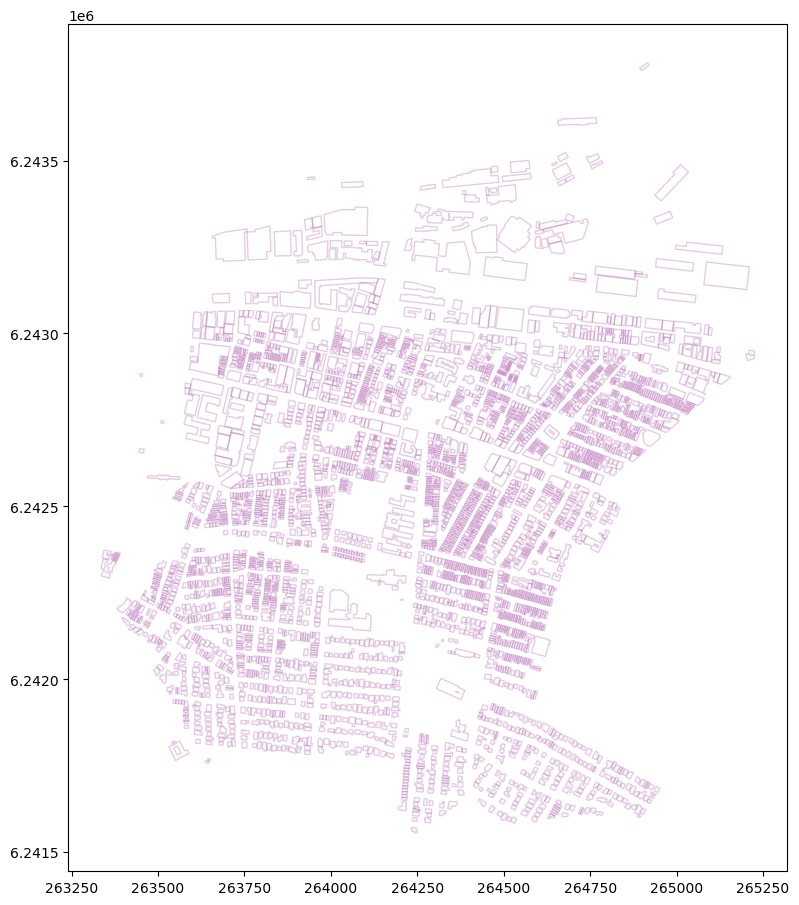

In [41]:
#-plot
def plot_geometries(df, ax=None, facecolor='none', edgecolor='purple', alpha=0.5):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10,10))

    patches = []

    for geom in df['geometry']:
        if geom is None:
            continue

        if isinstance(geom, Polygon):
            # Exterior ring
            patches.append(MplPolygon(list(geom.exterior.coords), closed=True))
            # Interiors (holes)
            for interior in geom.interiors:
                patches.append(MplPolygon(list(interior.coords), closed=True))
        elif isinstance(geom, MultiPolygon):
            for poly in geom.geoms:
                patches.append(MplPolygon(list(poly.exterior.coords), closed=True))
                for interior in poly.interiors:
                    patches.append(MplPolygon(list(interior.coords), closed=True))

    pc = PatchCollection(patches, facecolor=facecolor, edgecolor=edgecolor, alpha=alpha)
    ax.add_collection(pc)
    ax.autoscale()
    ax.set_aspect('equal')
    return ax

# Example usage:
fig, ax = plt.subplots(figsize=(11, 11))
plot_geometries(gdf_copy, ax=ax, facecolor='none', edgecolor='purple', alpha=0.2)
if len(new_df1) > 0:
    plot_geometries(new_df1, ax=ax, facecolor='none', edgecolor='red', alpha=0.5)
#-- save
plt.savefig('../data/topologyFig', dpi=300)
#plt.show()

|  |  |
|:--------:|:--------:|
| ![ue-error.png](../data/ue-error.png)| **Challenges will be highlight in *'Red'***|
| ![ue.png](../data/ue.png)| **or none**|

<h2><center> If you continue without fixing the challenges, the BVPC value will not be true.  <br /><br /> Our goal is to be as representative as possible. </center></h2>

**If necessary; edit [OpenStreetMap](https://www.openstreetmap.org/about) and fix the challenge please.** 

<div class="alert alert-block alert-warning"><b>  </b> 

And remember.  
Geofabrik releases a ***fresh `.osm.pbf` EVERYDAY!***  
Give the OpenStreetMap server ***at least a day*** before attempting the process again.
    
**Alchemy is a process. Please be patient.**
</div>

<div class="alert alert-block alert-success"><b>BVPC = total population of a community divided by sum of building volume</b></div>

In [42]:
#- area and volume
gdf2['area'] = gdf2['geometry'].apply(lambda geom: geom.area if geom else 0)
gdf2['volume'] = gdf2['area'] * gdf2['building_height']

#- remove the volume of the ground floor (unoccupied) when building:levels > 7 [this is an arbitrary number based on local knowledge]
#- typically this space is reserved for some other function: retail, etc. 
gdf2['volume'] = [
    (row['volume'] - row['area'] * 2.8) if (
        ('social_facility' not in gdf2.columns or pd.isna(row.get('social_facility')))
        and row['building:levels'] > 7
        and row['building'] in ['residential', 'apartments', 'student']
    ) else row['volume']
    for _, row in gdf2.iterrows()
]

gdf2['bvpc'] = np.where(
    gdf2['pop'] > 0,
    gdf2['volume'] / gdf2['pop'],
    np.nan
)

In [43]:
print(gdf2['bvpc'].describe())

count    2981.000000
mean      145.563987
std       100.883083
min        30.084609
25%        89.679216
50%       116.849891
75%       165.807902
max      2308.915241
Name: bvpc, dtype: float64


In [44]:
bvpc = round(gdf2['volume'].sum() / est_pop, 3)
#bvpc = round( est_pop / gdf2['volume'].sum(), 3)

print('Building Volume Per Capita (BVPC):', bvpc)

Building Volume Per Capita (BVPC): 272.216


<div class="alert alert-block alert-info"><b></b>

**This BVPC value is for all buildings with a `population > 0`. Buildings people live in** *(homes)*. 

And we can seperate `building:house` from `building:cabin` and `building:residential` to undertand the differences between ***formal and informal*** housing in this area.
    
**We want to understand the living space *(the cubic-meter BVPC value)* each person has in their home**
</div>

In [45]:
#- formal
formal = gdf2[gdf2["building"].isin(['house', 'semidetached_house', 'terrace', 'terraced', 'apartments'])].copy()
f_pop = int(formal['pop'].sum())

#- informal
informal = gdf2[gdf2["building"].isin(['residential', 'cabin'])].copy()
inf_pop = int(informal['pop'].sum())

#- student
stu = gdf2[gdf2["building"].isin(['student', 'dormitory'])].copy()
stu_pop = int(stu['pop'].sum())

bvpc_formal = round(formal['volume'].sum() / formal['pop'].sum(), 3)
bvpc_informal = round(informal['volume'].sum() / informal['pop'].sum() if informal['pop'].sum() != 0 else 0, 3)
bvpc_stu = round(stu['volume'].sum() / stu['pop'].sum() if stu['pop'].sum() != 0 else 0, 3)

print('FORMAL: Population: ', f_pop, ' with Building Volume Per Capita (BVPC):', bvpc_formal)
print('')
print('STUDENT RESIDENCE: Population: ', stu_pop, ' with Building Volume Per Capita (BVPC):', bvpc_stu)
print('')
print('INFORMAL: Population: ', inf_pop, ' with Building Volume Per Capita (BVPC)', bvpc_informal)

FORMAL: Population:  15738  with Building Volume Per Capita (BVPC): 142.166

STUDENT RESIDENCE: Population:  45  with Building Volume Per Capita (BVPC): 109.497

INFORMAL: Population:  1279  with Building Volume Per Capita (BVPC) 77.813


<div class="alert alert-block alert-danger"><b>Warning: </b>
    

These are LoD1 3D City Models.  
LoD2 would offer a more representative BVPC [(Ghosh, T; et al. 2020)](https://www.researchgate.net/publication/343185735_Building_Volume_Per_Capita_BVPC_A_Spatially_Explicit_Measure_of_Inequality_Relevant_to_the_SDGs) value; when the complexity of the built environment increases.  

Think about a `house` with living space in the roof structure, so called *'attic living'*, or an `apartment` building with different levels, loft apartments and/or units in the turrets of a building.  

***consider***: this area seperates [building:cabin](https://wiki.openstreetmap.org/wiki/Tag:building%3Dcabin) from `building:residential` to more precisely represent informal structures without typical roof trussess but account for [social housing](https://en.wikipedia.org/wiki/Public_housing) that does</div></div>

## 3. Further examples of Spatial Data Science *(renewable energy)*:

<div class="alert alert-block alert-warning"><b></b>

**Let's attempt to understand the % of homes and population served with renewable energy.**
</div>
    
[**SDG**](https://sdgs.un.org/goals) indicators are typically calculated at **region and national scales**.  
Here, because we are working with highly detailed, local data, we can explore what a [**Tier 3 local indicator**](https://unstats.un.org/sdgs/metadata/) might look like at a ***neighbourhood level***.
<br>

In this section 3. we evaluate [**SDG 7: Ensure access to affordable, reliable, sustainable and modern energy for all**](https://sdgs.un.org/goals/goal7) at a community level and estimate the **proportion of residential units and population** that have **direct access to on-site renewable energy infrastructure** *--rooftop photovoltaic panels (PV) and solar water heaters (SWH)*.

- Percentage of **households** served by rooftop renewable energy  
- Percentage of the **population** served by rooftop renewable energy
- And then we go even further to estimate the **Annual Solar Potential in MWh** *(theoretical maximum electricity)* that homes can harvest from the sun over the course of one year.

In [46]:
#- harvest solar
gdf_solar_combined = city3D._harvestSolar(input_pbf, minx, miny, maxx, maxy, epsg)

if len(gdf_solar_combined) < 0:
    print("\033[1m No solar generator features found.\033[0m No rooftop solar are mapped in", focus)

In [47]:
#- look
gdf_solar_combined.head(2)

,geometry,osm_id,other_tags,z_order
0,POLYGON ((265277.85421120946 6242363.049765201...,1045126952,"""generator:method""=>""photovoltaic"",""generator:...",0
1,"POLYGON ((265272.3012488816 6242352.679363036,...",1045126953,"""generator:method""=>""photovoltaic"",""generator:...",0


In [48]:
# Apply conversion function
gdf_solar_combined["tags"] = gdf_solar_combined["other_tags"].apply(safe_convert)

# Extract values safely - Normalize the 'tags' column to create a new DataFrame
tags_df = pd.json_normalize(gdf_solar_combined['tags'])
# Join the new columns back to the original GeoDataFrame
gdf_solar_combined = pd.concat([gdf_solar_combined, tags_df], axis=1)
# (Optional) Drop the original 'tags' column
gdf_solar_combined = gdf_solar_combined.drop(columns=['other_tags', 'tags'])

# Ensure a single 'osm_id' column
if 'osm_id' in gdf_solar_combined.columns:
    if 'osm_way_id' in gdf_solar_combined.columns:
        gdf_solar_combined['osm_id'] = [o if pd.notna(o) else w 
                         for o, w in zip(gdf_solar_combined['osm_id'], gdf_solar_combined['osm_way_id'])]
        gdf_solar_combined = gdf_solar_combined.drop(columns=['osm_way_id'])
elif 'osm_way_id' in gdf_solar_combined.columns:
    gdf_solar_combined = gdf_solar_combined.rename(columns={'osm_way_id': 'osm_id'})

gdf_solar_combined = gdf_solar_combined[gdf_solar_combined.geometry.apply(lambda x: x.within(shapely.unary_union(aoi.geometry)))]

#-look
gdf_solar_combined.head(2)

,geometry,osm_id,z_order,generator:method,generator:output:electricity,generator:source,generator:type,location,power,generator:output:hot_water,operator,operator:type,operator:wikidata
68,"POLYGON ((263921.6015001162 6242122.983059727,...",1097018218,0,thermal,NaN,solar,solar_thermal_collector,rooftop,generator,yes,NaN,NaN,NaN
69,POLYGON ((263923.64292556536 6242122.734229784...,1097018219,0,thermal,NaN,solar,solar_thermal_collector,rooftop,generator,yes,NaN,NaN,NaN


In [49]:
#- the number of renewable in the AREA
gdf_solar_combined['generator:method'].value_counts()

generator:method
thermal         25
photovoltaic    23
Name: count, dtype: int64

In [50]:
#- solar renewable is not connected to the buildings. connect the solar to the approproate building 
#- add 'children' and 'has_solar' columns to buildings and 'parent' to solar
gdf2, gdf_solar_combined = city3D._with_solar(gdf2, gdf_solar_combined, epsg)

gdf2.head(2)

,osm_id,address,building,building:levels,building:use,building:flats,building:units,beds,rooms,residential,...,footprint,geometry,fill_color,pop,area,volume,bvpc,children,has_solar,method
1,12227309,The Neighbourgoods Market Woodstock Cape Town,retail,1.0,NaN,0,0,0,0,NaN,...,"(((18.4580079, -33.9273091), (18.4585296, -33....","POLYGON ((265023.4813864499 6242993.344091462,...","[253, 141, 60]",NaN,822.291163,3371.393767,NaN,None,False,[]
2,12249345,Church Square 34 Dickson Street 7915 Woodstoc...,apartments,6.0,NaN,105,0,0,0,NaN,...,"(((18.450818, -33.9279241), (18.4508644, -33.9...",POLYGON ((264360.39058643614 6242908.633245183...,"[252, 194, 3]",315.0,1419.142674,25686.482393,81.544389,None,False,[]


In [51]:
#--we only want buildings people live in (homes). building=house or =apartment or =residential, etc.
gdf2 = gdf2[gdf2["building"].isin(['house', 'semidetached_house', 'terrace', 'terraced', 'apartments', 'residential', 'dormitory', 'cabin', 'student', 'garage'])].copy()

<div class="alert alert-block alert-success"><b>Percentage of households served by rooftop renewable energy</b></div>

$$ \text{\% homes with renewable energy} = \frac{\text{Number of dwellings with mapped solar PV and SWH}}{\text{Total number of dwellings}} \times 100 $$

In [52]:
#- harvest columns
with_solar = sum(gdf2["has_solar"])
pop = est_pop #gdf["pop"]
total_homes = len(gdf2)

solHms = round((with_solar / total_homes) * 100, 2)

print('\033[1m Percentage homes, \033[0m in', jparams['FocusArea'],', with rooftop photovoltaic panels (PV) and solar water heaters (SWH):', solHms)

 Percentage homes,  in Woodstock , with rooftop photovoltaic panels (PV) and solar water heaters (SWH): 0.79


<div style="text-align: left;"> 
<small> <b>NB:</b> this number includes the <a href="https://wiki.openstreetmap.org/wiki/Tag:building%3Dgarage">OpenStreetMap <code>building=garage</code></a> building type. Go to <code>Cell &plusmn;48</code> to exclude this building type from the estimate.</small>
</div>
<br>
<div class="alert alert-block alert-success"><b>Percentage of population served by rooftop renewable energy</b></div>

$$ \text{\% population with renewable energy} = \frac{\text{Number of residents with mapped solar PV and SWH}}{\text{Estimated population}} \times 100 $$

In [53]:
pop_total = gdf2["pop"].sum()
pop_solar = gdf2["pop"][gdf2["has_solar"]].sum()

solPop = round(pop_solar / pop_total * 100, 2)

print('\033[1m Percentage population, \033[0m in', jparams['FocusArea'],', with rooftop photovoltaic panels (PV) and solar water heaters (SWH):', solPop)

 Percentage population,  in Woodstock , with rooftop photovoltaic panels (PV) and solar water heaters (SWH): 0.54


In [54]:
# number of solar renewable on HOMES
gdf2['method'].explode().value_counts()

method
thermal         22
photovoltaic    13
Name: count, dtype: int64

### 3. b) Solar potential (MWh)

<div class="alert alert-block alert-warning"><b></b>

In this section, we attempt to understand how much ***'fuel'*** a rooftop can get from the sun.
</div>

<div class="alert alert-block alert-info"><b></b> 
    
**PLEASE SUPPLY YOUR OWN `ghi.tif`. The `ghi.tif` raster comes with the `LTAy_YearlySum.GeoTiff` dataset.**  
These can be harvested from the [Global Solar Atlas](https://data360.worldbank.org/en/dataset/WB_SOLAR_ATLAS)** *--a World Bank Group and ESMAP project--* **[download section](https://globalsolaratlas.info/download) and are available for each country on Earth.**  

</div>

We will query the **Global Horizontal Irradiation (GHI**) dataset. This high-resolution raster uses a combination of satellite observations and advanced meteorological models to tell us the *'solar weight'* hitting our neighborhood.

> **Source:** The **Global Solar Atlas GHI Raster** provides a ~20-year historical average of solar radiation. This ensures our communities solar potential is based on **long-term climate trends** rather than a single year of weather.
>   
> **Goal:**
> To calculate the Annual Total GHI (kWh/m2/year). This value tells us the cumulative **'solar pressure'** hitting our rooftops over an entire year, which we then use to calculate **how many Megawatt-hours (MWh) of clean electricity our neighborhood can generate**.
>

In [55]:
#- where is the GHI.tif
raster_file = "../raster/GHI.tif"

In [56]:
#- harvest GHI value from raster

# 1. Setup Raster Access once (Outside the loop)
ds = gdal.Open(raster_file)
gt = ds.GetGeoTransform()
rb = ds.GetRasterBand(1)

# Setup Transformation (OSM/GDF 4326 -> Raster CRS)
target = osr.SpatialReference()
target.ImportFromWkt(ds.GetProjection())
source = osr.SpatialReference()
source.ImportFromEPSG(4326)
transform = osr.CoordinateTransformation(source, target)

def get_ghi_per_building(geom):
    """
    Queries the raster at the specific centroid of the provided geometry.
    Uses the pre-loaded transform and raster band for speed.
    """
    if not geom:
        return 0.0
    
    # Get the specific centroid for this building
    centroid = geom.centroid
    
    # Transform point to Raster's CRS
    # Note: TransformPoint expects (x, y) which is (lon, lat) in 4326
    point = transform.TransformPoint(centroid.x, centroid.y)
    
    # Map Map Coordinates to Pixel Coordinates
    # px = (X_geo - X_origin) / PixelWidth
    # py = (Y_geo - Y_origin) / PixelHeight
    px = int((point[0] - gt[0]) / gt[1])
    py = int((point[1] - gt[3]) / gt[5])
    
    try:
        # Read a 1x1 window at the calculated pixel coordinates
        structval = rb.ReadAsArray(px, py, 1, 1)
        return float(structval[0][0])
    except:
        return 0.0

# 2. Execution
# Ensure your GDF is in 4326 to match the transformer logic
gdf2 = gdf2.to_crs('EPSG:4326')

# Apply the function to each row's unique geometry
gdf2['ghi_yearly'] = gdf2['geometry'].apply(get_ghi_per_building)

print("Annual Average GHI:", round(gdf2['ghi_yearly'].mean(),2) ,"kWh/m²/year")

Annual Average GHI: 1891.36 kWh/m²/year


<div class="alert alert-block alert-success"><b>Annual Solar Potential (MWh)</b></div>

We use a simplified formula to provide a clear baseline.

$$
\text{Potential (MWh)} = \frac{(\text{Surface Area} \times \text{utilization factor}) \times \text{GHI}_{\text{annual}} \times 0.2}{1000}
$$


<div class="alert alert-block alert-warning"><b></b>

<sub>***Theoretical Framework:** The annual energy output of a photovoltaic system (E) is determined by the product of the total solar resource (GHI), the active area of the array (A), and the system's overall efficiency (η), adjusted by a Performance Ratio (PR) to account for real-world losses. — based on [NREL (2022)](https://joint-research-centre.ec.europa.eu/photovoltaic-geographical-information-system-pvgis_en) & [IEC 61724-1](https://webstore.iec.ch/en/publication/65561). We then adapt this formula and represents a combined value of 25% nominal panel efficiency and a 0.80 Performance Ratio with a **single 0.20 system efficiency value and account for usable area**, a heuristic for gabled roofs.*</sub> 
</div>

<div class="alert alert-block alert-danger"><b>Your Participation! </b>
    
**Fill in the `utilization_factor` below** 
</div>

As a **'rule-of-thumb'** a community with traditional gabled houses: `utilization_factor = 0.4` *(less than half)*, while a high-density suburb with flat-roofed apartments: `utilization_factor = 0.6`

In [57]:
# on average, how much of the roof faces the sun? Adjust based on roof types
utilization_factor = 0.4

In [58]:
# Potential (MWh) = (Area * GHI_Yearly * 0.20) / 1000
gdf2['solar_mwh'] = ((gdf2['area'] * utilization_factor) * gdf2['ghi_yearly'].mean() * 0.20) / 1000
gdf2.head(2)

,osm_id,address,building,building:levels,building:use,building:flats,building:units,beds,rooms,residential,...,fill_color,pop,area,volume,bvpc,children,has_solar,method,ghi_yearly,solar_mwh
2,12249345,Church Square 34 Dickson Street 7915 Woodstoc...,apartments,6.0,NaN,105,0,0,0,NaN,...,"[252, 194, 3]",315.0,1419.142674,25686.482393,81.544389,None,False,[],1899.0,214.729127
3,12286281,Cissie Gool House Victoria Walk Woodstock 7925...,residential,4.0,residential,310,0,0,0,NaN,...,"[119, 3, 252]",930.0,5308.084580,66351.057251,71.345223,None,False,[],1895.0,803.161225


In [59]:
average_solar_potential = gdf2['solar_mwh'].mean()
print("\033[1mThe average solar potential, per home\033[0m, for", jparams['FocusArea'], "is:", round(average_solar_potential, 2), "MWh/year")

The average solar potential, per home, for Woodstock is: 19.89 MWh/year


<div style="text-align: left;"> 
<small> <b>NB:</b> this number includes the <a href="https://wiki.openstreetmap.org/wiki/Tag:building%3Dgarage">OpenStreetMap <code>building=garage</code></a> building type. Go to <code>Cell &plusmn;48</code> to exclude this building type from the estimate.</small>
</div>
<br>
<div class="alert alert-block alert-info"><b></b>
   
What does this **MWh/year** value mean?
<br>
    
To put the value in context, **15 MWh/year:**  
- is enough to provide **100% of the electricity** for 4 to 5 average UK homes *(which use ~3.4 MWh each)* or 1.5 average US homes *(~10.7 MWh each)*
- is enough power to drive an Electric Vehicle for **75,000 kilometers** *--that’s almost two full trips around the Earth*.
- roughly saves **10 metric tons of Carbon Dioxide** from entering the atmosphere.
    
</div>

<div class="alert alert-block alert-danger"><b>Sanity Check!</b>
<br>

- In <code>Cell &plusmn;48</code> we excluded non-residential building types `=office, commercial, retail, warehouse, industrial, etc.` from the analysis.
     
- Cape Town typically yields ~1.6–1.7 MWh **per installed kWp per year**; the higher per-household values reported here reflect **rooftop potential derived from available area** *--that considers a `utilization_factor`*, not a 1 kWp system.

    A 1 kWp solar PV system requires approximately 5–8 m² of panel area (e.g. panels of roughly 1 m × 1.7 m, depending on technology).

    We are NOT asking: How much energy (MWh/year) would a single 1 kWp PV system generate on a roof?  
    We are asking: **How much energy (MWh/year) could these roofs harvest, given their available area and a realistic utilization factor?**

- The **BVPC Warning** applies here too. These are **LoD1 3D City Models**, which represent buildings as simple extrusions.

  LoD2 models *—that capture roof form (e.g. gable, hipped, mansard, domes)—* would provide more representative estimates of both **BVPC and Average Annual Solar Potential**. In such cases, the `utilization_factor` becomes less critical, as usable roof geometry is explicitly modelled. 

</div>

**Now you do your community.** ~ If your area needs [OpenStreetMap](https://en.wikipedia.org/wiki/OpenStreetMap) data and you want to contribute please follow the [Guide](https://wiki.openstreetmap.org/wiki/Beginners%27_guide).

<a id='Section3'></a>

## 4. Possible Secondary and Tertiary level *conversations starters*:

<div class="alert alert-block alert-success"><b>communicate and exchange ideas and understanding</b></div>

| **Topic**                                | **Secondary Level Questions**                                                                                                                                                                                   | **Tertiary Level Questions**                                                                                                                                                                                                                   |
|------------------------------------------|-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **Geography** | - Talk about the main difference between a globe and a map, and why we use map projections to represent the Earth on a flat surface<br>- Explain why different map projections are used for different purposes. For example, why might a Mercator projection be useful for navigation, but not for comparing the sizes of countries? | - Discuss why it is necessary to convert geographic coordinates (latitude and longitude) to a projected coordinate system in the context of the geospatial sciences. What are some potential issues if this conversion is not done? <br>- How does geodesy contribute to the geospatial sciences?|
| **Basic Understanding and Observations** | - What types of buildings are most common in the area (houses, apartments, retail, etc.)?<br>- Can you identify any patterns in the distribution of different types of buildings (e.g., are retail stores concentrated in certain areas)? | - How does the building stock composition (e.g., ratio of houses) correlate with the population? *demographics (e.g., age distribution, household size for the area will strengthen the analysis!* <br>- Analyze the relationship between building density and population. What urban planning theories can explain this relationship? |
| **Spatial Relationships and Impacts**    | - How does the location of residential areas compare to the location of retail and commercial areas?<br>- What impact might the density and distribution of buildings have on local traffic and transportation?<br>- How might the population distribution affect the demand for local services such as schools, hospitals, and parks? | - Evaluate the accessibility of essential services (e.g., healthcare, education) in relation to the population and building types.<br>- Assess the potential social and economic impacts of a proposed new residential or commercial development in the area.                  |
| **Socioeconomic and Environmental Considerations** | - **How can an increase in the population of an urban area affect the demand for housing and public services?** *(conversely what do the results of  [village]() indicate?)*<br>- Are there any correlations between the types of housing available and the household size? *additional demographics (e.g., income level) for the area will strengthen the analysis!*<br>- How might the current building stock and population influence the local economy? *demographics (e.g., age distribution, household size) for the area will strengthen the analysis!*<br>- What are some potential environmental impacts of the current building distribution, such as green space availability or pollution levels? | - **What are the potential socio-economic and environmental challenges associated with rapid population growth in urban areas, and how can urban planners address these challenges?** *(conversely what do the results of  [village]() indicate?)*<br>- How does the current building stock support or hinder sustainable development goals (e.g., energy efficiency, reduced carbon footprint)?<br>- What strategies could be implemented to increase the resilience of the community to environmental or economic changes?                       |
| **Future Planning and Development**      | - Based on the current building stock and population metrics, what areas might benefit from additional housing or commercial development?<br>- How could urban planners use this information to improve the quality of life in the area?<br>- What changes would you recommend to better balance residential, commercial, and recreational spaces? | - How might different zoning regulations impact the distribution of residential, commercial, and industrial buildings in the future?<br>- Propose urban design solutions that could improve the sustainability and livability of the area, considering both current metrics and future projections. |
| **Quantitative and Qualitative Research** | |- Design a research study to investigate the impact of building type diversity on community wellbeing. What methodologies would you use?<br>- Analyze historical data to understand trends in building development and population growth. How have these trends shaped the current urban landscape?<br>- Conduct a SWOT analysis (Strengths, Weaknesses, Opportunities, Threats) of the area based on the building stock and population metrics. |

In [60]:
Tend = time.time()
print('runtime:', str(timedelta(seconds=(Tend - Tstart))))

runtime: 0:01:04.939001
